tao=Vy*Q/(I*t)

V：横截面上的剪力 (Shear Force)。

Q：所求接缝以外（或以上）部分面积对中性轴的静矩（First Moment of Area），Q=y′⋅A′

I：整个截面对中性轴的惯性矩（Moment of Inertia）。

b：接缝处的截面宽度（Width)

In [ ]:
#HW7.1. Get shear stress - Extruded cross-section
import numpy as np

b = 24e-3 # mm
t = 6e-3 # mm
Vy = 18e3 # kN


i1=(4*b+2*t)*(6*t+4*b)**3/12
i2=(2*t+2*b)*(2*b)**3/12+(2*t+2*b)*(2*b)*(2*t+b)**2
i3=2*t*(t)**3/12+2*t**2*(2.5*t+2*b)**2
I=i1-2*i2-2*i3

Q1=(1/2*t+2*b+2*t)*(2*b*t)
Q2=Q1+(2*t+b)*(2*b*b)
Q3=Q2+t*(2*t*(t+2*b))
t1=2*b
t2=b
t3=2*b+t

tao1=Q1*Vy/I/t1
tao2=Q2*Vy/I/t2
tao3=Q3*Vy/I/t3
print(max(tao1,tao2,tao3)/1e6)

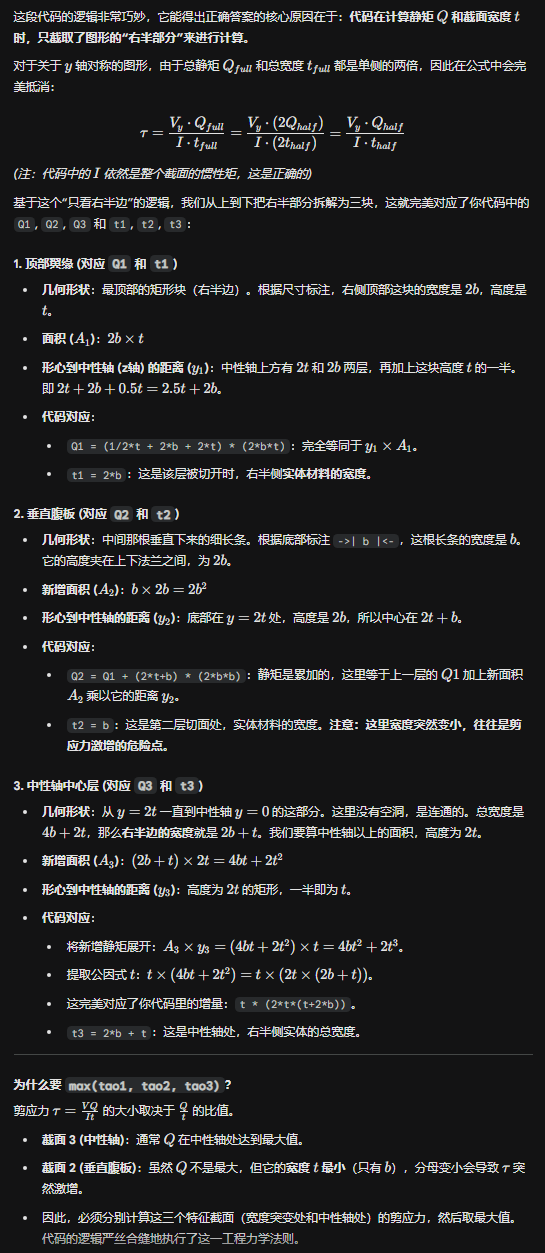

In [ ]:
#HW7.2. Get normal and shear stresses - U-channel - MultiPart
from sympy import *

t1 = 7 # mm
t2 = 10 # mm
b = 75 # mm
h = 71 # mm
ybar = 52.91686 # mm
Iz = 1124963.27771 # mm^4
Vy = 34 # kN
Mz = 605 # N.m

sigma=Mz*1000*(ybar)/Iz
print(f"tensile正应力 |σ| = ",abs(sigma), "MPa")

sigma=Mz*1000*(h+t2-ybar)/Iz
print(f"compressive正应力 |σ| = ",abs(sigma), "MPa")

#tao=Vy*Q/(I*t)
Vy= Vy*1000 # N

y1=t2/2+h-ybar
A1=t2*b
y2=1/2*(h-ybar)
A2=2*(h-ybar)*t1
Q=y1*A1+y2*A2

t=2*t1
tao=Vy*Q/(Iz*t) # MPa

print(f"最大剪应力 |τ| = ",abs(tao), "MPa")


In [ ]:
#HW7.3. Obtain the height of the rectangular beam
import numpy as np
from sympy import Symbol, solve
b = 72 # mm
a = 664 # mm
P = 13 # kN
sigmaAll = 128 # MPa
tauAll = 76 # MPa

p=P*1000 # N
b=b/1000 # m
a=a/1000 # m
sigmaAll=sigmaAll*1e6 # Pa
tauAll=tauAll*1e6 # Pa

h=Symbol('h')
I=b*h**3/12
M=p/2*a
c=h/2
sigma=M*c/I
h1=solve(sigma-sigmaAll, h)[1]
#print(h1)

Vy=p/2
q=h/4*(b*h/2)  
t=b
tao2=Vy*q/(I*t)
h2=solve(tao2-tauAll, h)[0]
#print(h2)

print("最终结果：h =", max(h1, h2)*1000, "mm")

In [ ]:
#HW7.4. Obtain width of the built-up beam
from sympy import *

h = 3 # in
a = 36 # in
P = 3 # kips
s1 = 3 # ksi
s2 = 250 # psi

p=P*1000
s1=s1*1000

b=Symbol('b')
I=b*(3*h)**3/12
M=p/2*a
c=1.5*h
sigma=M*c/I
b1=solve(sigma-s1, b)[0]
print(b1)

Vy=p/2
q=1.5*h/2*(b*h*3/2)   
t=b
tao2=Vy*q/(I*t)
b2=solve(tao2-s2, b)[0]
print(b2)

print("最终结果：b =", max(b1, b2), "in")

In [ ]:
#HW7.5. Determine the required shear strength of a glue
from sympy import *

b = 35 # mm
V = 5 # kN

v=V*1000
b=b*0.001


q=b*(3*b)*3*b/2
t=b

i1=3*b*(4*b)**3/12
i2=b*(2*b)**3/12
I=i1-2*i2
#print(I)
tao=v*q/I/t
print(tao/1e6)

In [ ]:
#HW7.6. Obtain spacing between bolts
from sympy import *

h = 192 # mm
t = 37 # mm
d = 12 # mm
taub = 3 # MPa
V = 2 # kN



h=h/1000
t=t/1000
d=d/1000
taub=taub*1e6
v=V*1000

a=np.pi*d**2/4
sigma=v/a

ybar=(h*t*2*h/2+h*t*h)/(3*h*t)

i1=t*h**3/12+h*t*(h/2-ybar)**2
i2=t*h**3/12+h*t*(h-ybar)**2
I=2*i1+i2
print(I)

y1=h-ybar
A1=h*t
Q1=y1*A1

q=v*Q1/I
print(q)
A=1/4*pi*d**2

F=taub*A


s=2*F/q 

print(float(s)*1e3)


In [ ]:
#HW7.7. Obtain shear stress in each bolt

from sympy import *

b = 215 # mm
t = 44 # mm
d = 14 # mm
deltaS = 108 # mm
Vy = 4 # kN

mm=1e-3;b*=mm;t*=mm;d*=mm;deltaS*=mm;Vy*=1e3



I1=1/12*b*(b+2*t)**3
I2=1/12*(b-2*t)*b**3

I=I1-I2
#print(I)
y1=1/2*b+1/2*t
A1=b*t
Q=y1*A1
#最上面那条的面积距


q=Vy*Q/I

Fzong=q*deltaS
F1=1/2*Fzong

A=d**2/4*pi

tao=F1/A
print(tao.evalf()/1e6)


In [ ]:
#HW7.8. Hollow Cylindrical Cross Section: Shear Stress
from sympy import *

D = 203 # mm
d = 102 # mm
V = 40 # kN

D=D/1000
d=d/1000
V=V*1000

I=np.pi/4*((D/2)**4-(d/2)**4)
print(I*1e6)

Q=2/3*((D/2)**3-(d/2)**3)
print(Q*1e6)

tao=V*Q/I/(D-d)
print(tao/1e6)

In [ ]:
#HW7.9. Compare shear stress in each nail
#我不明白
import numpy as np

b = 39 # in
t = 6 # in
d = 0.71 # in
deltaS = 51 # in
Vmax = 5 # lb


I1=1/12*t*b**3
I2=1/12*b*t**3+(b/2+t/2)**2*b*t
I=I1+2*I2

print(I/1e3)

y1=1/2*b+t/2
A1=t*b

Q1=y1*A1
V=S('V')

q=V*Q1/I
print(solve(Vmax-q*deltaS))


y2=1/2*b+t/2
A2=(b/2-t/2)*t
Q2=y2*A2
V=S('V')
q=V*Q2/I
print(solve(Vmax-q*deltaS))

